# GIPCA Illustration: ALS vs Grassmannian

Compare two GIPCA estimators on simulated data:
- **ALS GIPCA** — Alternating Least Squares with free latent factors
- **Grassmannian GIPCA** — Riemannian Conjugate Gradient via pymanopt

Full model:
$$r_t = Z_t \Gamma f_t + \varepsilon_t, \qquad f_t = f^0_t + \Delta' m_t, \qquad f^0_t \perp m_t$$

Both solve the profiled IPCA loss over $\Gamma$:
$$\min_{\Gamma:\,\Gamma'\Gamma=I_K} \frac{1}{T}\sum_t \min_f \|r_t - Z_t\Gamma f\|^2$$

then recover $\Delta$ and $f^0_t$ via time-series OLS post-estimation, with the identification constraint $f^0_t \perp m_t$.

In [1]:
import sys, os, time
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt

from src.generate.gipca import generate_gipca_data
from src.models.als_gipca import HardGIPCA
from src.models.grassmanian_gipca import GrassmannManifoldGIPCAEstimator
from src.utils import subspace_error, recovery_report

## 1. Generate Synthetic Data

In [2]:
seed = 6890
np.random.seed(seed)

T = 63          # time periods
N = 500         # assets
m = 25          # characteristics
k = 5           # latent factors
num_macro = 3   # macro variables

data, truth = generate_gipca_data(
    T=T, N=N, m=m, k=k, num_macro=num_macro,
    include_intercept=False,
    seed=seed,
)

rets, Z, mu = data
W_star = truth["W_star"]
Delta_star = truth["Delta_star"]

print(f"Returns shape:          {rets.shape}  (T x N)")
print(f"Characteristics shape:  {Z.shape}  (T x N x m)")
print(f"Macro shape:            {mu.shape}  (T x num_macro)")
print(f"True Gamma shape:       {W_star.shape}  (m x k)")
print(f"True Delta shape:       {Delta_star.shape}  (k x num_macro)")

Returns shape:          (63, 500)  (T x N)
Characteristics shape:  (63, 500, 25)  (T x N x m)
Macro shape:            (63, 3)  (T x num_macro)
True Gamma shape:       (25, 5)  (m x k)
True Delta shape:       (5, 3)  (k x num_macro)


## 2. Fit ALS GIPCA

In [3]:
als = HardGIPCA(
    num_assets=N, num_fact=k, num_charact=m,
    num_macro=num_macro, win_len=T,
)

t0 = time.time()
Gamma_als, hist_als = als.fit(
    data, max_iter=2000, tol=1e-6,
    verbose=True, truth=truth,
)
als_time = time.time() - t0

print(f"\nWall time: {als_time:.2f}s")
print(f"Identification check: || f0^T mu || = {np.linalg.norm(als.f0 @ mu):.2e}")

Init IPCA profiled loss: 2030.974524
Iteration    0: Objective = 2030.974524
Iteration   10: Objective = 209.031053, Obj change = 1.36e-16, Param change = 5.09e-13
Iteration   20: Objective = 209.031053, Obj change = 1.36e-16, Param change = 4.41e-13
Iteration   30: Objective = 209.031053, Obj change = 0.00e+00, Param change = 4.43e-13
Iteration   40: Objective = 209.031053, Obj change = 2.72e-16, Param change = 4.37e-13
Iteration   50: Objective = 209.031053, Obj change = 1.36e-16, Param change = 4.35e-13
Iteration   60: Objective = 209.031053, Obj change = 0.00e+00, Param change = 4.39e-13
Iteration   70: Objective = 209.031053, Obj change = 2.72e-16, Param change = 4.44e-13
Iteration   80: Objective = 209.031053, Obj change = 1.36e-16, Param change = 4.43e-13
Iteration   90: Objective = 209.031053, Obj change = 1.36e-16, Param change = 4.41e-13
Iteration  100: Objective = 209.031053, Obj change = 1.36e-16, Param change = 4.35e-13

Converged after 100 iterations
Initial objective: 20

## 3. Fit Grassmannian GIPCA (Riemannian CG)

In [4]:
grass = GrassmannManifoldGIPCAEstimator(
    num_assets=N, num_fact=k, num_charact=m,
    num_macro=num_macro, win_len=T,
)

t0 = time.time()
Wopt, Delta_grass, f0_grass, f_grass, hist_grass = grass.fit(
    data,
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=2,
    truth=truth,
)
grass_time = time.time() - t0

print(f"\nWall time: {grass_time:.2f}s")
print(f"Identification check: || f0^T mu || = {np.linalg.norm(f0_grass.T @ mu):.2e}")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
  1          +2.6853861507547863e+03    1.61879491e+03    
  2          +1.4750980464048894e+03    1.10190392e+03    
  3          +9.8201202843374097e+02    9.38463886e+02    
  4          +7.5305706552406411e+02    7.11944335e+02    
  5          +6.2754684994614752e+02    5.59220468e+02    
  6          +4.6387684378829198e+02    4.74344786e+02    
  7          +3.5796608883786786e+02    4.41853133e+02    
  8          +3.1375832811542205e+02    2.51734655e+02    
  9          +2.9655456683995823e+02    1.98374484e+02    
 10          +2.7605542607223123e+02    1.60524017e+02    
 11          +2.5614592366217204e+02    2.63702125e+02    
 12          +2.3619877947041118e+02    1.31674463e+02    
 13          +2.3266730096291775e+02    1.02397916e+02    
 14          +2.2906762437521675e+02    8.51994036e+01    
 15          +2.2535085984289634e+02    9.

## 4. Recovery Reports

In [5]:
print("ALS GIPCA")
metrics_als = recovery_report(Gamma_als, truth, Delta_hat=als.Delta)

print("\nGrassmannian GIPCA")
metrics_grass = recovery_report(Wopt, truth, Delta_hat=Delta_grass)

ALS GIPCA

=== Recovery Report ===
Grassmann distance:      0.042325
Principal angles (deg):  [1.4947, 1.4579, 0.8593, 0.7249, 0.5073]
Max principal angle:     1.494651 deg
RMS principal angle:     1.084501 deg
Delta Grassmann dist:    1.493648

Grassmannian GIPCA

=== Recovery Report ===
Grassmann distance:      0.042325
Principal angles (deg):  [1.4947, 1.4579, 0.8593, 0.7249, 0.5073]
Max principal angle:     1.494650 deg
RMS principal angle:     1.084501 deg
Delta Grassmann dist:    1.718317


## 5. Comparison Plots

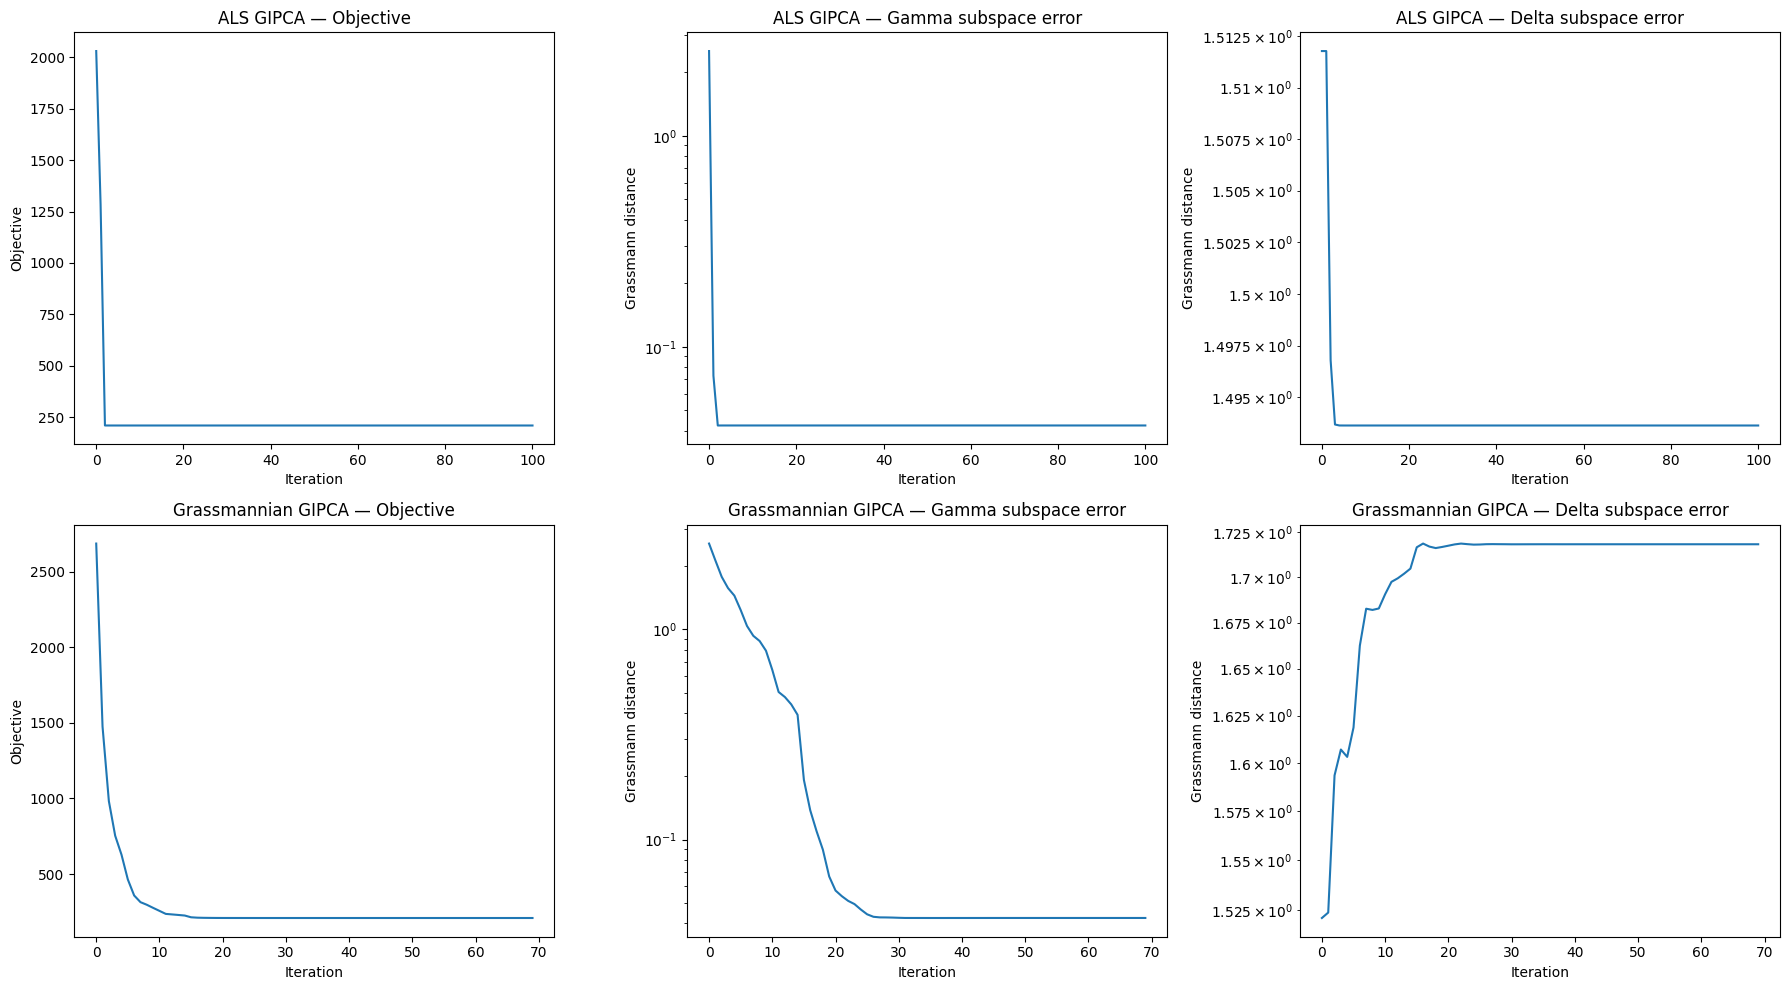

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- ALS row ---
axes[0, 0].plot(hist_als)
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Objective")
axes[0, 0].set_title("ALS GIPCA — Objective")

axes[0, 1].plot(als.gamma_error_history)
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Grassmann distance")
axes[0, 1].set_title("ALS GIPCA — Gamma subspace error")
axes[0, 1].set_yscale("log")

axes[0, 2].plot(als.delta_error_history)
axes[0, 2].set_xlabel("Iteration")
axes[0, 2].set_ylabel("Grassmann distance")
axes[0, 2].set_title("ALS GIPCA — Delta subspace error")
axes[0, 2].set_yscale("log")

# --- Grassmannian row ---
axes[1, 0].plot(hist_grass)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Objective")
axes[1, 0].set_title("Grassmannian GIPCA — Objective")

axes[1, 1].plot(grass.gamma_error_history)
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Grassmann distance")
axes[1, 1].set_title("Grassmannian GIPCA — Gamma subspace error")
axes[1, 1].set_yscale("log")

axes[1, 2].plot(grass.delta_error_history)
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].set_ylabel("Grassmann distance")
axes[1, 2].set_title("Grassmannian GIPCA — Delta subspace error")
axes[1, 2].set_yscale("log")

plt.tight_layout()
plt.show()

## 6. Summary

In [7]:
print(f"{'':30s} {'ALS':>12s}  {'Grassmann':>12s}")
print("-" * 56)
print(f"{'Final objective':30s} {hist_als[-1]:12.4f}  {hist_grass[-1]:12.4f}")
print(f"{'Gamma Grassmann dist':30s} {metrics_als['grassmann_dist']:12.6f}  {metrics_grass['grassmann_dist']:12.6f}")
print(f"{'Delta Grassmann dist':30s} {metrics_als.get('delta_grassmann_dist', float('nan')):12.6f}  {metrics_grass.get('delta_grassmann_dist', float('nan')):12.6f}")
print(f"{'Iterations':30s} {len(hist_als)-1:12d}  {len(hist_grass):12d}")
print(f"{'Wall time (s)':30s} {als_time:12.2f}  {grass_time:12.2f}")

                                        ALS     Grassmann
--------------------------------------------------------
Final objective                    209.0311      209.0311
Gamma Grassmann dist               0.042325      0.042325
Delta Grassmann dist               1.493648      1.718317
Iterations                              100            70
Wall time (s)                          2.73          1.69
